# K-Means Clustering — Classical ML Notes

---

## Supervised vs Unsupervised — The Big Shift

Everything studied so far (Linear/Logistic Regression, KNN, Naive Bayes, SVM, Decision Trees, Random Forest, XGBoost) was **supervised**: `X` (features) **and** `y` (the correct answer/label) were both available, and the model learned to map one to the other.

**Unsupervised learning has no `y` at all.** Only `X` — raw data with no labels, no "correct answers." The goal isn't to predict something known; it's to **discover structure** already hiding in the data.

```
Supervised:    "Here's X and the correct answer y, learn the relationship"
Unsupervised:  "Here's just X — find interesting patterns/groups on your own"
```

**K-Means Clustering** is the most common unsupervised algorithm: given unlabeled data, group similar points together into clusters.

---

## Core Idea

Given data points and a number `K` (how many groups desired), K-Means:
1. Finds `K` **cluster centers** (called "centroids")
2. Assigns every data point to whichever centroid is **closest**
3. Moves each centroid to the **average position** of the points assigned to it
4. Repeats until the centroids stop moving (convergence)

**Example:** Customer data with "annual spending" and "visit frequency" — K-Means might naturally discover 3 groups: budget-conscious occasional shoppers, frequent big spenders, and everything in between — without ever being told what those groups should look like.

---

## The Algorithm, Step by Step

```
1. Choose K (number of clusters) — decided upfront
2. Randomly place K centroids in the feature space
3. Repeat until convergence:
   a. ASSIGNMENT STEP: assign each data point to its nearest centroid
      (Euclidean distance — same metric as KNN)
   b. UPDATE STEP: move each centroid to the mean position of all
      points currently assigned to it
4. Stop when centroids no longer move (or move below a tiny threshold),
   or after a max number of iterations
```

```
Iteration 0: Centroids placed randomly
    x    x       x           ● (centroid 1, random)
  x    x    x                        ● (centroid 2, random)
    x       x

Iteration 1: Points assigned to nearest centroid, centroids move to the mean
    x    x  →  ●(1)    x           
  x    x    x                 ●(2)  x
    x       x

Iteration 2+: Repeat until centroids stabilize — clusters emerge naturally
```

---

## The Math

**Assignment:** for each point $x_i$, assign to cluster $j$ minimizing distance:
$$\text{cluster}(x_i) = \arg\min_j \; ||x_i - \mu_j||^2$$

**Update:** new centroid = mean of all points assigned to that cluster:
$$\mu_j = \frac{1}{|C_j|}\sum_{x_i \in C_j} x_i$$

**Overall objective — Inertia / Within-Cluster Sum of Squares (WCSS):**
$$\text{Inertia} = \sum_{j=1}^{K}\sum_{x_i \in C_j} ||x_i - \mu_j||^2$$

Lower inertia = points tightly packed around their centroids = tighter, more well-defined clusters.

---

## Feature Scaling (Same Reasoning as KNN)

K-Means is entirely distance-based — an unscaled large-range feature will dominate the distance calculation and distort the clusters. **Always scale before K-Means, no exceptions.**

---

## Choosing K — The Central Practical Challenge

Unlike supervised learning, there's no "correct" K given upfront — no ground truth to check against.

### Method 1: Elbow Method
Run K-Means for a range of K values (e.g. 1–10), plot inertia against K. Inertia always decreases as K increases, but with diminishing returns. Look for the "elbow" — where adding more clusters stops giving a meaningful drop in inertia.

```
Inertia
  |  •
  |    •
  |       •
  |          •___•___•___•___•     ← the "elbow" is around here
  |________________________________ K
     1  2  3  4  5  6  7  8  9  10
```

### Method 2: Silhouette Score
Measures how similar a point is to its own cluster compared to other clusters. Range: -1 to 1.
- Close to 1 → well-matched to its own cluster, far from others (good)
- Close to 0 → on the boundary between two clusters
- Negative → possibly assigned to the wrong cluster

Compute average silhouette score across all points, for each candidate K — pick the K with the **highest** average score. Generally considered more reliable than the elbow method, since "where's the elbow" can be subjective to eyeball, while silhouette gives a concrete comparable number.

---

## Critical Weakness: Random Initialization Sensitivity

Since centroids start at random positions, different runs can converge to genuinely different (sometimes worse) clusterings — K-Means can get stuck in a "locally good but globally bad" solution depending on unlucky starting points.

**Fix: K-Means++** — a smarter initialization strategy that spreads out initial centroids intelligently (instead of pure random placement), making it far less likely to get stuck in a bad local solution. This is sklearn's default behavior.

---

## Other Real Limitations

- Assumes clusters are roughly **spherical/round and similarly sized** — struggles with elongated, oddly-shaped, or very differently-sized clusters
- **Sensitive to outliers** — a single extreme point can drag a centroid noticeably off-center, since the centroid is a mean
- **K must be chosen in advance** — the algorithm won't tell you the "correct" number of natural groups on its own
- **Only works well on numeric features** — categorical data needs special handling (or a different algorithm, like K-Modes)

---

## Predicting on New Data

Once trained, K-Means can assign **new, unseen points** to whichever existing cluster centroid is closest — usable in production, not just a one-time analysis tool (e.g., assigning a brand-new customer to an existing customer segment).

---

## K-Means vs Supervised Models

| | Supervised Models (Logistic Regression, KNN, etc.) | K-Means |
|---|---|---|
| Needs labels (`y`)? | Yes | No |
| Goal | Predict a known target | Discover hidden groupings |
| Evaluation | Accuracy, F1, RMSE, etc. (compare to ground truth) | Inertia, Silhouette Score (no ground truth exists) |
| "Correct answer" exists? | Yes, in the data | No — clusters are a discovered pattern, not a verified fact |

---

## Real-World Use Cases

- **Customer segmentation** — grouping customers by purchasing behavior for targeted marketing
- **Image compression** — reducing an image's colors to K representative colors
- **Document/topic clustering** — grouping similar articles/documents without predefined categories
- **Anomaly detection** — points far from any centroid may be outliers/anomalies

---

## Summary

| Aspect | Value |
|---|---|
| Type | Unsupervised — no labels needed |
| Core idea | Partition data into K groups, minimizing distance to each group's centroid |
| Key hyperparameter | `K` (number of clusters) — must be chosen, not learned |
| Distance metric | Euclidean (same as KNN) |
| Needs scaling? | Yes, critical |
| Choosing K | Elbow Method or Silhouette Score |
| Initialization issue | Random starts can converge poorly → fixed by K-Means++ (sklearn default) |
| Weaknesses | Assumes round/similar-sized clusters, sensitive to outliers, must pre-specify K |
| Evaluation | Inertia (lower = better), Silhouette Score (higher = better) |



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Toy dataset: customers with annual spending and visit frequency
data = {
    'annual_spending': [15, 20, 18, 75, 80, 85, 22, 78, 19, 82, 16, 76],
    'visit_frequency':  [5,  6,  4,  2,  3,  2, 5,   3,  6,  1,  5,  2]
}

df = pd.DataFrame(data)
print(df)

    annual_spending  visit_frequency
0                15                5
1                20                6
2                18                4
3                75                2
4                80                3
5                85                2
6                22                5
7                78                3
8                19                6
9                82                1
10               16                5
11               76                2


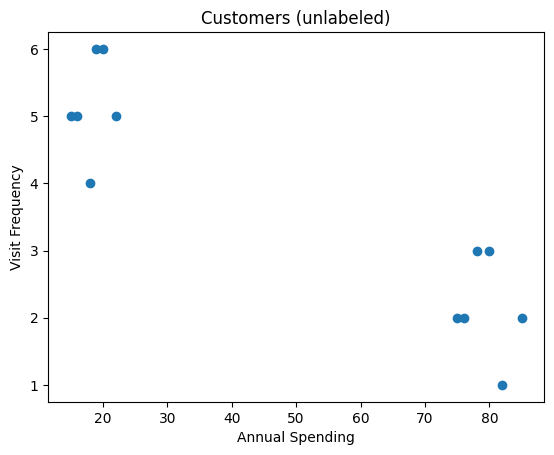

In [2]:
plt.scatter(df['annual_spending'], df['visit_frequency'])
plt.xlabel('Annual Spending')
plt.ylabel('Visit Frequency')
plt.title('Customers (unlabeled)')
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

X = df[['annual_spending', 'visit_frequency']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

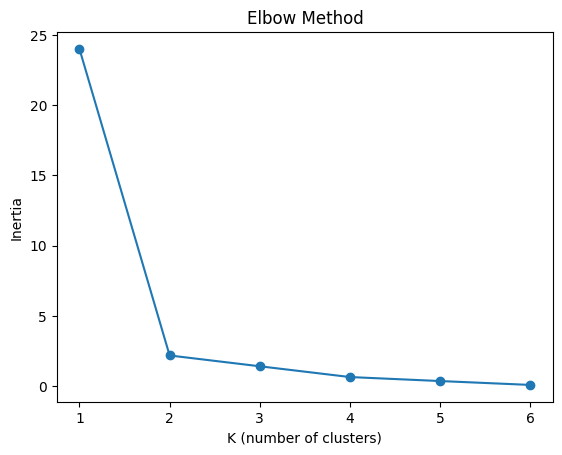

In [4]:
#find the best k - elbo method

from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 7)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('K (number of clusters)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [5]:
#silhouette method

from sklearn.metrics import silhouette_score

for k in range(2, 7):  # silhouette needs at least 2 clusters
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} → Silhouette Score: {score:.3f}")

K=2 → Silhouette Score: 0.787
K=3 → Silhouette Score: 0.713
K=4 → Silhouette Score: 0.627
K=5 → Silhouette Score: 0.638
K=6 → Silhouette Score: 0.657


In [6]:
model = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
model.fit(X_scaled)

# Get cluster assignment for each original point
df['cluster'] = model.labels_
print(df)

    annual_spending  visit_frequency  cluster
0                15                5        1
1                20                6        1
2                18                4        1
3                75                2        0
4                80                3        0
5                85                2        0
6                22                5        1
7                78                3        0
8                19                6        1
9                82                1        0
10               16                5        1
11               76                2        0


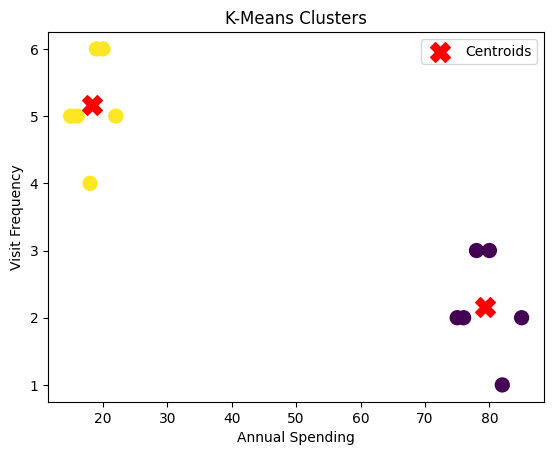

In [7]:
plt.scatter(df['annual_spending'], df['visit_frequency'], c=df['cluster'], cmap='viridis', s=100)

# Plot centroids too (need to inverse-transform since they're in scaled space)
centroids_original = scaler.inverse_transform(model.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.xlabel('Annual Spending')
plt.ylabel('Visit Frequency')
plt.title('K-Means Clusters')
plt.legend()
plt.show()

In [8]:
new_customer = [[70, 3]]   # high spending, low visits
new_customer_scaled = scaler.transform(new_customer)

predicted_cluster = model.predict(new_customer_scaled)
print(f"New customer belongs to cluster: {predicted_cluster[0]}")

New customer belongs to cluster: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Hierarchical Clustering — Classical ML Notes

---

## Core Idea

Unlike K-Means (which requires choosing K upfront), Hierarchical Clustering builds a **complete tree of nested clusters** — starting from individual points and merging them step by step, all the way up to one giant cluster containing everything. The number of clusters is decided by "cutting" this tree at whatever level makes sense, **after** seeing the whole structure.

---

## Two Approaches

**Agglomerative (Bottom-Up)** — the common one, what sklearn implements:
- Start: every point is its own cluster
- Repeatedly merge the two **closest** clusters into one
- Continue until everything is merged into a single cluster

**Divisive (Top-Down)** — the reverse, far less common in practice:
- Start: all points in one giant cluster
- Repeatedly split into smaller clusters
- Continue until every point is its own cluster

---

## The Algorithm, Step by Step (Agglomerative)

```
1. Start with each data point as its own cluster (n points = n clusters)
2. Find the two closest clusters
3. Merge them into one cluster
4. Repeat steps 2-3 until only one cluster remains
5. Record every merge and the distance at which it happened — this record IS the dendrogram
```

---

## Linkage Methods — Measuring Distance Between Clusters

A single point's "closest" is just distance (Euclidean, same as KNN/K-Means). Once clusters have multiple points, **linkage** defines how distance between two clusters is measured — a genuinely new concept not present in earlier algorithms.

| Linkage Method | How it measures cluster distance |
|---|---|
| **Single linkage** | Distance between the **closest** pair of points (one from each cluster) |
| **Complete linkage** | Distance between the **farthest** pair of points (one from each cluster) |
| **Average linkage** | Average distance across **all** pairs of points between the two clusters |
| **Ward's method** | Merges whichever pair of clusters causes the **smallest increase in total within-cluster variance** |

**Ward's method is the most common default** — tends to produce more balanced, compact clusters, similar in spirit to what K-Means optimizes for (minimizing within-cluster spread).

**Single linkage** can create "chained" elongated clusters — a weakness, since it can accidentally connect distant points through a chain of intermediate points. **Complete linkage** tends to produce more compact, evenly-sized clusters but can be sensitive to outliers.

---

## The Dendrogram — The Key Visual Output

```
Distance
  |
  |           ┌─────────────┐
  |           |             |
  |      ┌────┴────┐    ┌───┴───┐
  |      |         |    |       |
  |    ┌─┴─┐     ┌─┴─┐  A       B
  |    |   |     |   |
  |    C   D     E   F
```

- **Height of each merge** = the distance at which those two clusters were joined (lower merge = more similar clusters)
- **Cutting the tree horizontally** at any height determines the final number of clusters — cut high up → fewer, bigger clusters; cut low → more, smaller clusters

This allows deciding K **after** seeing the data's structure, rather than guessing beforehand like K-Means requires.

---

## Important Limitation: No Predicting New Points

A genuine, practical difference from K-Means: Agglomerative Clustering **cannot directly assign a brand-new, unseen point to a cluster** — the entire clustering was built by merging the specific points it was given; there's no centroid to compare a new point against.

If new points need to be classified later, a common workaround is training a separate supervised classifier (like KNN) using the discovered cluster labels as the target `y`.

---

## Hierarchical Clustering vs K-Means

| | K-Means | Hierarchical Clustering |
|---|---|---|
| Must choose K upfront? | Yes | No — decide after seeing the dendrogram |
| Output | Just final cluster assignments | Full tree of all possible groupings |
| Can predict new points? | Yes | No — would need a separate model |
| Scalability | Handles large datasets well | Slower, doesn't scale well to very large datasets (expensive pairwise distances) |
| Cluster shape assumption | Roughly spherical | More flexible, depends on linkage method chosen |
| Randomness | Sensitive to random centroid init (mitigated by k-means++) | Deterministic — same data always gives the same dendrogram |

---

## Why It's Still Useful Despite Being Slower

- **The dendrogram itself is valuable** — shows relationships/similarity at every level, not just one fixed K. Useful for exploratory data analysis, even without training a "final" model
- **No randomness** — fully deterministic, reproducible without needing multiple random restarts (unlike K-Means)
- **Doesn't force committing to K before seeing the data's actual structure**
- Common in bioinformatics (gene expression clustering), taxonomy/classification systems, and exploratory analysis where nested relationships matter more than one clean partition

---

## Evaluation

Same approach as K-Means — no ground truth exists, so evaluation relies on **Silhouette Score** or visual dendrogram inspection, rather than cross-validation against known labels.

---

## Summary

| Aspect | Value |
|---|---|
| Type | Unsupervised — no labels needed |
| Core idea | Build a tree of nested clusters by repeatedly merging the closest pair |
| Approaches | Agglomerative (bottom-up, common) or Divisive (top-down, rare) |
| Key new concept | Linkage methods (Ward, Single, Complete, Average) — how to measure distance between clusters |
| Output | Dendrogram — allows choosing K after training, visually |
| Needs scaling? | Yes, critical |
| Can predict new points? | No — a real limitation vs K-Means |
| Evaluation | Silhouette Score, or visual dendrogram inspection |
| Best for | Exploratory analysis, understanding nested relationships, smaller datasets |

---


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'annual_spending': [15, 20, 18, 75, 80, 85, 22, 78, 19, 82, 16, 76],
    'visit_frequency':  [5,  6,  4,  2,  3,  2, 5,   3,  6,  1,  5,  2]
}
df = pd.DataFrame(data)

X = df[['annual_spending', 'visit_frequency']]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

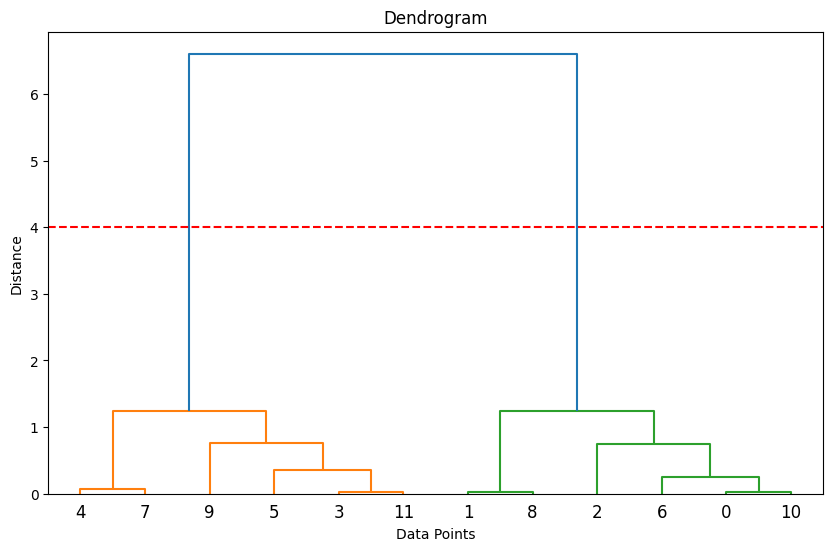

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 'ward' linkage — most common default
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked, labels=df.index.tolist())
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.title('Dendrogram')
plt.axhline(y=4, color='red', linestyle='--')  # example cut line
plt.show()

In [12]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = model.fit_predict(X_scaled)

df['cluster'] = labels
print(df)

    annual_spending  visit_frequency  cluster
0                15                5        0
1                20                6        0
2                18                4        0
3                75                2        1
4                80                3        1
5                85                2        1
6                22                5        0
7                78                3        1
8                19                6        0
9                82                1        1
10               16                5        0
11               76                2        1


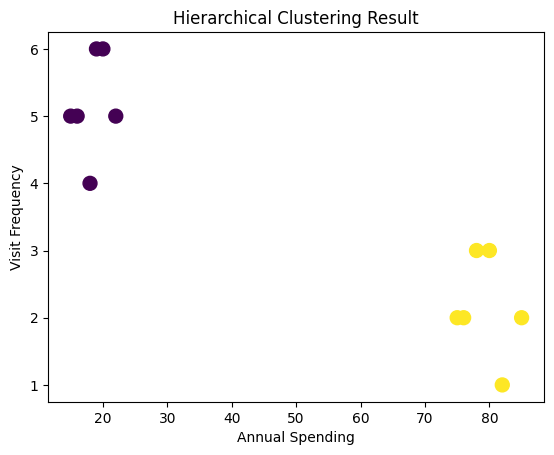

In [13]:
plt.scatter(df['annual_spending'], df['visit_frequency'], c=df['cluster'], cmap='viridis', s=100)
plt.xlabel('Annual Spending')
plt.ylabel('Visit Frequency')
plt.title('Hierarchical Clustering Result')
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.7873389525978496


# PCA (Principal Component Analysis) — Classical ML Notes

---

## The Core Problem PCA Solves

Real datasets often have many features, and:
- Some features are **redundant** (highly correlated — e.g., "height in cm" and "height in inches" carry the same information twice)
- Some features add more **noise** than useful signal
- High dimensionality makes data harder to visualize, slower to train on, and can hurt some models (curse of dimensionality)

**PCA's goal:** reduce the number of features while **keeping as much of the original information (variance) as possible.**

Unlike K-Means/Hierarchical Clustering (which *group* data), PCA **compresses** data — a genuinely different kind of unsupervised technique: dimensionality reduction, not clustering.

---

## Core Idea

Instead of dropping features (which loses information outright), PCA creates **brand new features** — **Principal Components** — that are combinations of the original features, ranked by how much variance (information) they capture.

```
Original: [height, weight, age, income, education_years]  (5 features)
                            ↓ PCA
New:      [PC1, PC2]  (2 features, but capturing most of the original variance)
```

Each Principal Component is a weighted combination of all original features:
$$PC_1 = w_1 \cdot \text{height} + w_2 \cdot \text{weight} + w_3 \cdot \text{age} + \dots$$

---

## Why "Variance" Specifically?

PCA's underlying assumption: **directions with more spread (variance) in the data contain more information.** A feature where all values are nearly identical tells almost nothing about individual data points; a feature with wide spread lets you meaningfully distinguish between points.

**Visual intuition (2D → 1D):**
```
Original 2D data (height vs weight, correlated):
    weight
      |    x
      |   x  x
      |  x  x  x
      | x  x  x
      |x  x
      |________________ height

PCA finds the direction of maximum spread (the diagonal line through the data)
This becomes PC1 — a single new axis that captures most of the original variance
```

Rotating the view to look straight down that diagonal compresses 2D data into 1D (PC1) while losing very little information — because that diagonal *was* where almost all the actual spread was happening.

---

## How PCA Finds These Directions (Conceptually)

1. **Standardize the data** (mean = 0, std = 1 for every feature) — essential
2. Calculate the **covariance matrix** — how every pair of features varies together
3. Calculate the **eigenvectors and eigenvalues** of that covariance matrix
   - **Eigenvectors** = the directions (the actual Principal Components)
   - **Eigenvalues** = how much variance is captured along each corresponding eigenvector
4. **Rank eigenvectors by eigenvalue** (largest first) — PC1 captures the most variance, PC2 the second most, and so on
5. **Keep only the top K components** that capture "enough" total variance, discard the rest

sklearn handles the eigenvector/eigenvalue computation internally — but knowing this is happening under the hood is useful for interviews.

---

## Key Property: Principal Components Are Uncorrelated

Each Principal Component is mathematically **orthogonal** (perpendicular) to all the others — they capture completely different aspects of the variance, with zero redundancy between them. A nice side benefit: the new features have no multicollinearity at all, unlike the original raw features might have had.

---

## Why Scaling Is Absolutely Mandatory

PCA is entirely based on **variance**, and variance is directly affected by scale. A feature measured in the thousands (like `income`) will always dominate the variance calculation over a feature measured in single digits (like `education_years`), regardless of which is actually more informative. **Always standardize before PCA — non-negotiable, even more strictly than KNN/SVM/K-Means.**

---

## Choosing How Many Components to Keep

### Explained Variance Ratio
Each component has an associated percentage of total variance explained. Look at the **cumulative** explained variance as components are added, and stop once "enough" is captured (commonly 90–95%).

```
PC1: 45% of variance
PC2: 25% of variance   → cumulative: 70%
PC3: 15% of variance   → cumulative: 85%
PC4: 8% of variance    → cumulative: 93%   ← might stop here
PC5: 4% of variance    → cumulative: 97%
```

### Scree Plot
Plot explained variance per component — similar visual logic to K-Means's elbow method. Look for the point where adding more components gives diminishing returns.

---

## Interpreting Components — Loadings

**Loadings** show how much each original feature contributes to each Principal Component. A large positive/negative value means that feature strongly influences that component — this is how PC1, PC2, etc. are interpreted in terms of the original data.

---

## Using PCA as Preprocessing Before a Supervised Model

A very common real-world use — reduce dimensionality first, then feed compressed features into a classifier/regressor.

**Important ordering rule (avoiding data leakage):** always split first, then fit `StandardScaler` on train only, transform both, then fit `PCA` on the scaled train data only, transform both. **PCA must be `fit()` only on training data, then `.transform()` on test data** — fitting PCA on test data is data leakage, the same principle as scaling.

---

## PCA's Big Trade-off: Interpretability Loss

This is PCA's most important practical downside: **Principal Components are combinations of original features, so they don't have inherent real-world meaning.** "PC1" isn't "study hours" — it's some blended mixture of study hours, sleep, attendance, etc. Great for improving model performance/visualization, but bad when needing to *explain* which original feature mattered (unlike Random Forest's feature importance, or Lasso's zeroed-out coefficients).

---

## When PCA Is Genuinely Useful

- **Visualization** — compress high-dimensional data down to 2D/3D to actually plot and look at it
- **Speeding up training** — fewer features = faster training for algorithms like SVM or KNN
- **Removing multicollinearity** — helpful before Linear/Logistic Regression, which assumes little multicollinearity
- **Noise reduction** — dropping low-variance components can remove noise, sometimes improving downstream model accuracy
- **Preprocessing before clustering** — running K-Means on PCA-reduced data can sometimes produce cleaner clusters

## When to Avoid It

- When **interpretability** of individual original features is needed
- When features are already few and not very correlated (not much redundancy to compress)
- When using tree-based models (Decision Tree, Random Forest, XGBoost) — they don't need PCA at all, since they naturally handle feature interactions and aren't distance-based

---

## PCA vs Everything Unsupervised Studied So Far

| | K-Means | Hierarchical Clustering | PCA |
|---|---|---|---|
| Goal | Group similar points | Group similar points (nested) | Reduce dimensionality |
| Output | Cluster labels | Dendrogram + cluster labels | New compressed features |
| Needs scaling? | Yes | Yes | Yes, absolutely mandatory |
| Can transform new data? | Yes | No | Yes |
| Choosing hyperparameter | K via elbow/silhouette | K via dendrogram cut | Number of components via explained variance |

---

## Summary

| Aspect | Value |
|---|---|
| Type | Unsupervised — dimensionality reduction (not clustering) |
| Core idea | Find new axes (Principal Components) that capture maximum variance |
| Key hyperparameter | `n_components` — chosen via explained variance / scree plot |
| Needs scaling? | Yes, absolutely mandatory |
| Components are | Uncorrelated with each other, ranked by variance captured |
| Biggest strength | Visualization, noise reduction, speeding up other models |
| Biggest weakness | Loses interpretability — components aren't real-world features |
| Common use | Preprocessing step before another model, or for visualizing high-dim data |



In [19]:
import pandas as pd
import numpy as np

data = {
    'hours_studied':    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'hours_slept':      [8, 7, 6, 6, 5, 5, 6, 7, 6, 8],
    'attendance_pct':   [60, 65, 70, 72, 75, 80, 85, 88, 92, 95],
    'practice_tests':   [2, 3, 3, 4, 5, 6, 7, 8, 9, 10],
    'anxiety_level':    [8, 7, 7, 6, 6, 5, 4, 3, 3, 2]
}

df = pd.DataFrame(data)
print(df)

   hours_studied  hours_slept  attendance_pct  practice_tests  anxiety_level
0              1            8              60               2              8
1              2            7              65               3              7
2              3            6              70               3              7
3              4            6              72               4              6
4              5            5              75               5              6
5              6            5              80               6              5
6              7            6              85               7              4
7              8            7              88               8              3
8              9            6              92               9              3
9             10            8              95              10              2


In [20]:
from sklearn.preprocessing import StandardScaler

X = df  # no target/y — this is unsupervised, using all columns as features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.decomposition import PCA

pca_full = PCA()  # no n_components specified = keeps all of them
pca_full.fit(X_scaled)

print("Explained variance ratio per component:", pca_full.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca_full.explained_variance_ratio_))

Explained variance ratio per component: [7.94831883e-01 2.01924129e-01 1.80958625e-03 1.15325062e-03
 2.81151166e-04]
Cumulative explained variance: [0.79483188 0.99675601 0.9985656  0.99971885 1.        ]


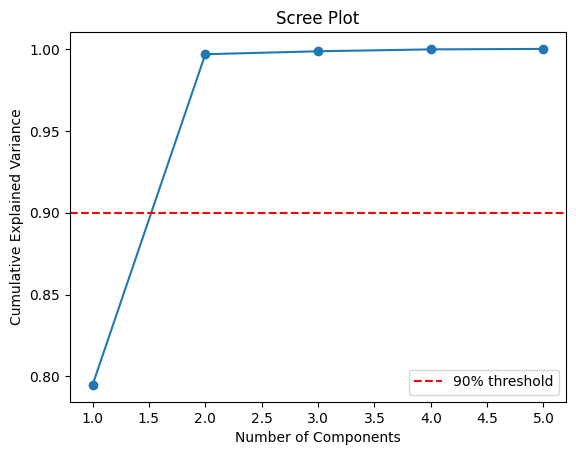

In [22]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1),
         np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.legend()
plt.show()

In [23]:
# Say the scree plot shows 2 components capture ~92% of variance
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])  # first 5 rows, now compressed from 5 features to 2
print("Variance explained by these 2 components:", pca.explained_variance_ratio_)
print("Total captured:", sum(pca.explained_variance_ratio_))

[[-3.05384124  1.59382657]
 [-2.21007591  0.61897721]
 [-1.81784658 -0.39836837]
 [-1.10221543 -0.38242633]
 [-0.60812757 -1.37762667]]
Variance explained by these 2 components: [0.79483188 0.20192413]
Total captured: 0.996756011961905


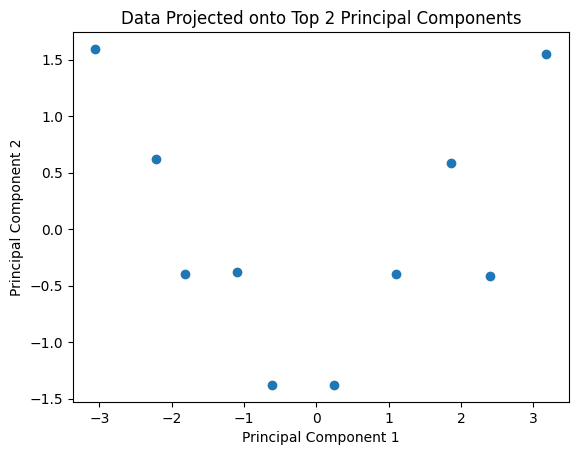

In [24]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Data Projected onto Top 2 Principal Components')
plt.show()

In [25]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
print(loadings)

                     PC1       PC2
hours_studied   0.500570 -0.047527
hours_slept     0.006725  0.995105
attendance_pct  0.500011 -0.055709
practice_tests  0.500201  0.031675
anxiety_level  -0.499172 -0.058316


In [26]:
#using pca in supervised model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Suppose we had a real y (pass/fail) to predict
y = [0,0,0,0,1,1,1,1,1,1]  # example labels

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [27]:
# Correct order to avoid leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit only on train
X_test_pca = pca.transform(X_test_scaled)           # transform only on test

using PCA with kmeans clustering

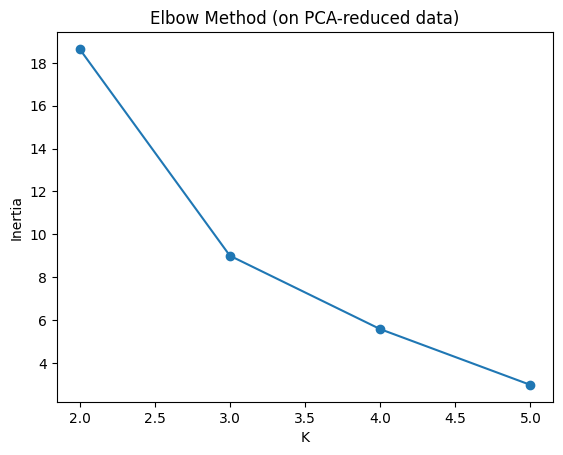

K=2 → Silhouette Score: 0.477
K=3 → Silhouette Score: 0.438
K=4 → Silhouette Score: 0.345
K=5 → Silhouette Score: 0.341


In [28]:
inertias = []
sil_scores = []
K_range = range(2, 6)  # small dataset, keep K range small

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

# Elbow plot
plt.plot(K_range, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method (on PCA-reduced data)')
plt.show()

# Silhouette scores
for k, score in zip(K_range, sil_scores):
    print(f"K={k} → Silhouette Score: {score:.3f}")

In [29]:
# Say K=2 looks best from the elbow/silhouette results
model = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
cluster_labels = model.fit_predict(X_pca)

df['cluster'] = cluster_labels
print(df)

   hours_studied  hours_slept  attendance_pct  practice_tests  anxiety_level  \
0              1            8              60               2              8   
1              2            7              65               3              7   
2              3            6              70               3              7   
3              4            6              72               4              6   
4              5            5              75               5              6   
5              6            5              80               6              5   
6              7            6              85               7              4   
7              8            7              88               8              3   
8              9            6              92               9              3   
9             10            8              95              10              2   

   cluster  
0        0  
1        0  
2        0  
3        0  
4        0  
5        0  
6        1  
7        1  
8 

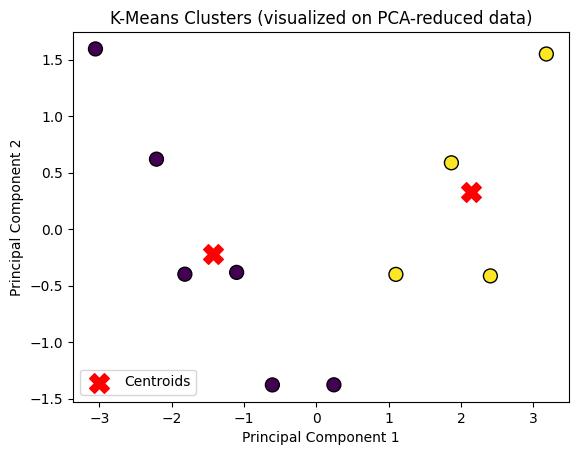

In [30]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=100, edgecolor='k')

centroids = model.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (visualized on PCA-reduced data)')
plt.legend()
plt.show()

In [31]:
new_student = [[6, 6, 78, 6, 5]]  # hours_studied, hours_slept, attendance_pct, practice_tests, anxiety_level

new_scaled = scaler.transform(new_student)      # must use the SAME scaler fitted earlier
new_pca = pca.transform(new_scaled)               # must use the SAME pca fitted earlier
predicted_cluster = model.predict(new_pca)

print("New student's cluster:", predicted_cluster[0])

New student's cluster: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
